# 01 Synthetic Day

Generate synthetic days of patient arrivals for the Phase 2 simulation. Each run writes a numbered file, `data/synthetic_days_{run_id:02d}.csv`; change `run_id` in `data/assumptions.yaml` for a new independent draw.

- **Arrivals:** non-homogeneous Poisson process per category. The daily rate is the mean daily admissions for the scenario's calendar month from `vcu_master_daily.csv`; the hourly shape is the shared diurnal curve in `appointment_arrivals`.
- **Stress test:** `code_red_winter` multiplies viral arrivals by 1.3. It is a what-if, not history.
- **Attributes:** severity, priority, scheduled flag, moveability, deadline, and unit from `assign_patient_attributes` (`patient_attributes` in `data/assumptions.yaml`). Scheduled deliveries and planned ICU admissions don't jump the queue.
- **Newborns** are not separate arrivals; they come with the mother (`maternal_newborn_couplet`).
- **Opening day:** the simulation starts with no occupied beds.

All values are synthetic. The hourly curve, rates per category, surge factor, scheduled shares, and severity are assumptions, not observed VCU data.

In [14]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from src.generators import assign_patient_attributes, generate_synthetic_day

with Path("data/assumptions.yaml").open(encoding="utf-8") as f:
    assumptions = yaml.safe_load(f)

day_settings = assumptions["synthetic_days"]
arrival_settings = assumptions["appointment_arrivals"]
attribute_settings = assumptions["patient_attributes"]
category_to_unit = assumptions["nurse_staffing"]["category_to_unit"]

master = pd.read_csv(day_settings["source_dataset"], parse_dates=["date"]).set_index("date")

## Validate inputs

In [15]:
admission_columns = [c for c in master.columns if c.startswith("admissions_")]
categories = [c.removeprefix("admissions_") for c in admission_columns
              if c.removeprefix("admissions_") not in day_settings["excluded_categories"]]
viral_categories = set(day_settings["viral_categories"])

scenario_rates = {}
for name, scenario in day_settings["scenarios"].items():
    dates = pd.date_range(scenario["start_date"], periods=scenario["days"], freq="D")
    assert dates.isin(master.index).all(), f"{name}: dates outside source data"
    month = master.loc[master.index.to_period("M") == dates[0].to_period("M"), admission_columns]
    assert dates.to_period("M").nunique() == 1, f"{name}: scenario spans two months"
    assert month.notna().all().all(), f"{name}: missing admissions in source month"
    assert (month >= 0).all().all(), f"{name}: negative admissions"
    multiplier = float(scenario["viral_rate_multiplier"])
    assert multiplier > 0, f"{name}: viral multiplier must be positive"
    # ASSUMPTION: stress-test scenarios scale viral arrivals on top of the reconstructed rate.
    scenario_rates[name] = {
        c: float(month[f"admissions_{c}"].mean()) * (multiplier if c in viral_categories else 1.0)
        for c in categories
    }

rates = pd.DataFrame(scenario_rates).round(2)
rates.loc["total"] = rates.sum()
rates.loc["label"] = [s["label"] for s in day_settings["scenarios"].values()]
rates

,code_red_winter,baseline_spring
delivery,13.58,14.39
non_elective_via_ed,15.77,14.55
non_elective_other,15.48,12.97
elective,15.52,14.1
covid_19,18.37,13.61
influenza,18.75,14.26
other_viral,20.0,14.29
intensive,13.23,13.32
total,130.7,111.49
label,stress_test,baseline


## Generate synthetic days

In [21]:
run_id = int(day_settings["run_id"])

def build_scenarios(seed: int, run_id: int) -> pd.DataFrame:
    frames = []
    for s_index, (name, scenario) in enumerate(day_settings["scenarios"].items()):
        dates = pd.date_range(scenario["start_date"], periods=scenario["days"], freq="D")
        for d_index, date in enumerate(dates):
            day_seed, attr_seed = np.random.SeedSequence([seed, run_id, s_index, d_index]).generate_state(2)
            # ASSUMPTION: every category shares the appointment_arrivals diurnal curve.
            day = generate_synthetic_day(
                date, scenario_rates[name],
                peak_hour=float(arrival_settings["peak_hour"]),
                amplitude=float(arrival_settings["amplitude"]),
                seed=int(day_seed),
            )
            day = assign_patient_attributes(day, attribute_settings, category_to_unit, seed=int(attr_seed))
            day.insert(0, "scenario", name)
            day.insert(0, "run_id", run_id)
            frames.append(day)
    return pd.concat(frames, ignore_index=True)

synthetic_days = build_scenarios(int(day_settings["seed"]), run_id)
print(f"Run {run_id:02d}: generated {len(synthetic_days):,} arrivals")
synthetic_days.head(10)

Run 01: generated 1,606 arrivals


,run_id,scenario,patient_id,date,category,arrival_time,severity,priority_rank,is_scheduled,is_moveable,move_window_days,deadline_date,unit
0,1,code_red_winter,20240108-covid_19-0001,2024-01-08,covid_19,2024-01-08 00:48:12,critical,1,False,False,<NA>,NaT,med_surg
1,1,code_red_winter,20240108-elective-0001,2024-01-08,elective,2024-01-08 00:48:41,low,4,False,True,30,2024-02-07,med_surg
2,1,code_red_winter,20240108-other_viral-0001,2024-01-08,other_viral,2024-01-08 01:15:46,low,2,False,True,0,2024-01-08,med_surg
3,1,code_red_winter,20240108-other_viral-0002,2024-01-08,other_viral,2024-01-08 01:27:33,medium,2,False,True,0,2024-01-08,med_surg
4,1,code_red_winter,20240108-non_elective_via_ed-0001,2024-01-08,non_elective_via_ed,2024-01-08 01:42:53,critical,1,False,False,<NA>,NaT,med_surg
5,1,code_red_winter,20240108-intensive-0001,2024-01-08,intensive,2024-01-08 02:03:37,critical,1,False,False,<NA>,NaT,icu
6,1,code_red_winter,20240108-delivery-0001,2024-01-08,delivery,2024-01-08 02:23:48,high,1,False,False,<NA>,NaT,labor_delivery
7,1,code_red_winter,20240108-other_viral-0003,2024-01-08,other_viral,2024-01-08 02:31:46,high,2,False,True,0,2024-01-08,med_surg
8,1,code_red_winter,20240108-non_elective_via_ed-0002,2024-01-08,non_elective_via_ed,2024-01-08 02:34:14,critical,1,False,False,<NA>,NaT,med_surg
9,1,code_red_winter,20240108-influenza-0001,2024-01-08,influenza,2024-01-08 02:36:28,low,2,False,True,0,2024-01-08,med_surg


## Validate output

In [22]:
assert synthetic_days.equals(build_scenarios(int(day_settings["seed"]), run_id)), "not reproducible"
assert synthetic_days["patient_id"].is_unique
assert not (synthetic_days["category"].isin(day_settings["excluded_categories"])).any()
assert (synthetic_days["arrival_time"].dt.date == synthetic_days["date"]).all()
assert not ((synthetic_days["category"] == "elective") & (synthetic_days["severity"] == "critical")).any()
assert not (synthetic_days["is_scheduled"] & (synthetic_days["severity"] == "critical")).any()
assert (synthetic_days.loc[synthetic_days["severity"] == "critical", "priority_rank"] == 1).all()

# Poisson check: each scenario's total arrivals should be within 3 SD of its expected total.
check = []
for name, scenario in day_settings["scenarios"].items():
    expected = sum(scenario_rates[name].values()) * scenario["days"]
    observed = (synthetic_days["scenario"] == name).sum()
    z = (observed - expected) / np.sqrt(expected)
    check.append({"scenario": name, "expected": round(expected, 1), "observed": observed, "z": round(z, 2)})
    assert abs(z) < 3, f"{name}: arrivals far from expected (z={z:.2f})"
display(pd.DataFrame(check))

per_day = synthetic_days.groupby(["scenario", "date", "category"]).size().unstack(fill_value=0)
display(per_day)

,scenario,expected,observed,z
0,code_red_winter,914.9,873,-1.38
1,baseline_spring,780.4,733,-1.70


category                    covid_19  delivery  elective  influenza  \
scenario        date                                                  
baseline_spring 2024-05-06        11        13         9         22   
                2024-05-07        18        11        19         11   
                2024-05-08        13        10        12         19   
                2024-05-09        13        14        10          9   
                2024-05-10        13         8        12         10   
                2024-05-11        16        16        15         10   
                2024-05-12        10         8        18         15   
code_red_winter 2024-01-08        10        11        22         19   
                2024-01-09        23         9        15         17   
                2024-01-10        22        10        11         14   
                2024-01-11        15        15        16         19   
                2024-01-12        15         6        10         12   
                2024-01-13        17         6        13         19   
                2024-01-14        14        13        16         17   

category                    intensive  non_elective_other  \
scenario        date                                        
baseline_spring 2024-05-06          8                   8   
                2024-05-07         12                  12   
                2024-05-08         12                  13   
                2024-05-09         16                  15   
                2024-05-10         11                   7   
                2024-05-11         21                   8   
                2024-05-12         13                  17   
code_red_winter 2024-01-08         15                  13   
                2024-01-09         15                  11   
                2024-01-10         19                  17   
                2024-01-11         17                  14   
                2024-01-12         14                  18   
                2024-01-13         16                  16   
                2024-01-14         13                  15   

category                    non_elective_via_ed  other_viral  
scenario        date                                          
baseline_spring 2024-05-06                   16           14  
                2024-05-07                   14           15  
                2024-05-08                    7           13  
                2024-05-09                   15           13  
                2024-05-10                   18           11  
                2024-05-11                   14           16  
                2024-05-12                   11           18  
code_red_winter 2024-01-08                   17           17  
                2024-01-09                   21           20  
                2024-01-10                   18           26  
                2024-01-11                   14           18  
                2024-01-12                   14           21  
                2024-01-13                   15           14  
                2024-01-14                   15           24

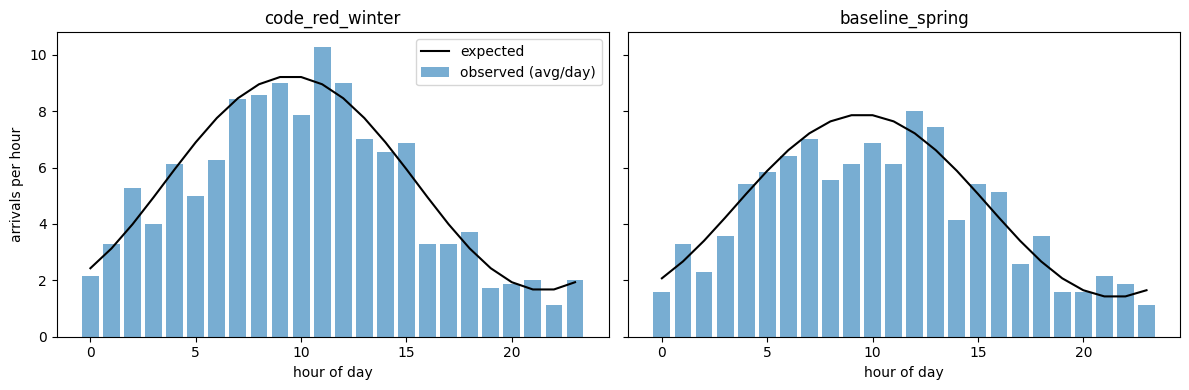

In [23]:
# Observed hourly arrivals vs. the expected diurnal curve, per scenario (average per day).
hours = np.arange(24)
amplitude = float(arrival_settings["amplitude"])
peak_hour = float(arrival_settings["peak_hour"])

fig, axes = plt.subplots(1, len(day_settings["scenarios"]), figsize=(12, 4), sharey=True)
for ax, (name, scenario) in zip(np.atleast_1d(axes), day_settings["scenarios"].items()):
    subset = synthetic_days[synthetic_days["scenario"] == name]
    observed = subset["arrival_time"].dt.hour.value_counts().reindex(hours, fill_value=0) / scenario["days"]
    # Hourly expectation integrates the cosine intensity over each hour.
    w = 2 * np.pi / 24
    integral = 1 + amplitude * (np.sin(w * (hours + 1 - peak_hour)) - np.sin(w * (hours - peak_hour))) / w
    expected = sum(scenario_rates[name].values()) / 24 * integral
    ax.bar(hours, observed, alpha=0.6, label="observed (avg/day)")
    ax.plot(hours + 0.0, expected, color="black", label="expected")
    ax.set_title(name)
    ax.set_xlabel("hour of day")
axes[0].set_ylabel("arrivals per hour")
axes[0].legend()
plt.tight_layout()
plt.show()

In [24]:
summary = synthetic_days.groupby("scenario").agg(
    arrivals=("patient_id", "size"),
    priority_1=("priority_rank", lambda s: (s == 1).sum()),
    scheduled=("is_scheduled", "sum"),
    moveable=("is_moveable", "sum"),
    car_wait_eligible=("move_window_days", lambda s: (s == 0).sum()),
)
summary["priority_1_share"] = (summary["priority_1"] / summary["arrivals"]).round(3)
display(summary)
display(pd.crosstab(synthetic_days["category"], synthetic_days["priority_rank"]))
display(pd.crosstab(synthetic_days["scenario"], synthetic_days["severity"]))

# ASSUMPTION: opening day; Phase 2 starts every scenario with no occupied beds.
assert day_settings["initial_state"] == "empty"
initial_census = pd.DataFrame({
    name: {
        "initial_occupied_beds": 0,
        "month_mean_occupied_beds_reference": round(master.loc[
            master.index.to_period("M") == pd.Timestamp(s["start_date"]).to_period("M"),
            "total_occupied_beds"].mean(), 1),
    }
    for name, s in day_settings["scenarios"].items()
}).T
initial_census

,arrivals,priority_1,scheduled,moveable,car_wait_eligible,priority_1_share
scenario,,,,,,
baseline_spring,733,228,39,337,242,0.311
code_red_winter,873,259,34,410,307,0.297


priority_rank,1,2,3,4
category,,,,
covid_19,37,173,0,0
delivery,119,0,31,0
elective,0,0,0,198
influenza,41,172,0,0
intensive,160,0,42,0
non_elective_other,35,0,149,0
non_elective_via_ed,59,150,0,0
other_viral,36,204,0,0


severity,low,medium,high,critical
scenario,,,,
baseline_spring,190,155,236,152
code_red_winter,203,216,268,186


,initial_occupied_beds,month_mean_occupied_beds_reference
code_red_winter,0.0,714.6
baseline_spring,0.0,660.5


In [25]:
output_path = Path(day_settings["output_dataset"].format(run_id=run_id))
synthetic_days.to_csv(output_path, index=False)
print(f"Saved {len(synthetic_days):,} arrivals to {output_path}")

Saved 1,606 arrivals to data\synthetic_days_01.csv
